# **Introduction**

This interactive notebook introduces a predictive model of melanopsin phototransduction (described in our publication: Nguyen and Caval-Holme et al. 2026). In the future we intend to update this notebook with more explanatory detail. For now, the publication is an essential reference.

Here, we demonstrate how to intialize the coding environment, create light stimuli, and predict the resulting melanopsin activity.  

## Workflow overview

1. Create a light stimulus. This can be completely synthetic data or based on spectra and intensities that you measure. The examples below walk through methods and considerations for creating light stimuli.

2. Run the model on the light stimulus using the ```predictMelanopsin()``` function. The model has many configurable parameters but default values are a good starting point. We explain how to configure parameters in the Appendix.

3. Visualize the results of the model run using the ```plotModelRun()``` function.


## How this notebook works

—*Optional read for those unfamiliar with Jupyter Notebooks/Google Colab* —

We recommend running this notebook in Google Colab: https://colab.research.google.com/
:
Colab will run this notebook in your browser. **You do not need to download, install, or configure anything on your own hardware.** Under the hood, the code runs on cloud computing hardware. This means that **your session is impermanent** — you will need to download any data or plots you wish to save.

We recommend running the whole notebook at once by clicking the `Run all` button at the top of your screen. To run individual code cells, click the **play button** next to each or hit `ctrl+enter` while you have a code cell selected. To stop code execution, hit the stop button next to the running code cell or use the menu option **Runtime>Interrupt execution**. If you edit values in a code cell, you have to re-run it and every code cell that depends on these values for your changes to take effect.

You can edit existing code cells or add your own; we recommend exploring in this way to build intuition with the model. If your modifications 'break' the notebook, you can re-download the original from  https://github.com/Do-Laboratory/melanopsin-model

The **table of contents** is helpful when navigating the notebook. To open it, click the top button on the left sidebar. You can also run the code within a section—mouse over the the table of contents section and a play button will pop up.

# **Initialization**

Run the code below (**ctrl+enter**, or **click the play button**) to intialize this session. This takes 1-2 minutes but only has to be done once per session.

In [ ]:
# Ensure we're in the repo root (clone only on Colab when needed; see myutils/notebook_setup.py)
import os
import subprocess

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

def _in_repo(p=None):
    p = p or os.getcwd()
    return os.path.isdir(os.path.join(p, "myutils")) and os.path.isfile(os.path.join(p, "requirements.txt"))

if _in_colab and not _in_repo():
    try:
        from google.colab import userdata
        _url = f"https://{userdata.get('GITHUB_TOKEN')}@github.com/Do-Laboratory/melanopsin-model.git"
    except Exception:
        print("Could not access private github repo")
        _url = "https://github.com/Do-Laboratory/melanopsin-model.git"
    subprocess.run(["git", "clone", "-b", "Finalizing", _url], check=True)
    os.chdir("melanopsin-model")
elif not _in_repo() and not _in_colab:
    _parent = os.path.dirname(os.path.abspath(os.getcwd()))
    if _in_repo(_parent):
        os.chdir(_parent)

# Install required libraries and load model (repo root is now cwd)
!pip install -q -r requirements.txt

# Imports model functions into the workspace and ensures Arial font is available
from myutils import *
globals().update(load())

# Can't run if there's no access to the custom libraries
sanityCheckMelanopsinFunction()

Cloning into 'melanopsin-model'...
remote: Enumerating objects: 1792, done.
remote: Counting objects: 100% (257/257), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 1792 (delta 172), reused 158 (delta 82), pack-reused 1535 (from 2)
Receiving objects: 100% (1792/1792), 623.04 MiB | 33.90 MiB/s, done.
Resolving deltas: 100% (944/944), done.
Updating files: 100% (150/150), done.
/content/melanopsin-model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00
Arial installed and active (/usr/share/fonts/truetype/msttcorefonts/arial.ttf)
Sanity Checked for melanopsin_function


# **Examples**

## monochromatic light (synthetic)

The ```predictMelanopsin()``` function requires a light stimulus protocol. Here, we construct a protocol consisting of increasingly intense steps of 440 nm light—a staircase. The protocol consists of **stimulus intervals**; we specify when each starts and ends, along with light's intensity and spectrum during the interval. There is darkness during any time in the protocol not covered by a stimulus interval. Preset double-train xenon protocols from ```setupModelRun``` (for example stimulus type ```"xenon"```) list only real light pulses as intervals; the long gap between the two identical intensity ladders is that implicit darkness, not a separate interval row. The light stimulus protocol (called here ```monochromatic_staircase```) is implemented as a **dictionary**—a data structure containing a set of **keys** paired with a corresponding set of **values**. The four required keys are the words **'ti', 'intensities', 'timings', and 'wlen**'. The values are accessed (using the keys) as follows:
```
monochromatic_staircase['ti']           # Total length of the experiment in seconds
monochromatic_staircase['intensities']  # Intensities of light in photons/micron^2
monochromatic_staircase['timings']      # stimulus interval list [(start time, stop time), ...]
monochromatic_staircase['wlen']         # Wavelength of light in nm
```

Note that this is a synthetic light stimulus. Under the hood, the model converts the integer wavelengths to an idealized spectrum for each stimulus interval. In later examples we will show how to construct stimulus protocols from spectrometer measurements.


In [2]:
# Create dictionary that will specify the light stimulus protocol
monochromatic_staircase = {}

# Duration of the experiment in seconds
monochromatic_staircase['ti'] = 660

# For n intervals have 2n entries.
monochromatic_staircase['timings'] = np.array([0,60, 60,120, 120,180, 180,240, 240,300, 300,360, 360,420])
# Here we provide (start_time, stop_time) tuples for clarity, but tuples are not required. np.array([0,60,60,120,120,180,180,240,240,300,300,360,360,420]) also works

# Light intensity during each interval.
monochromatic_staircase['intensities'] = np.array([10**1, 10**2, 10**3, 10**4, 10**5, 10**6, 10**7])

# Light's wavelength during each interval
monochromatic_staircase['wlen'] = np.array([440, 440, 440, 440, 440, 440, 440])

```predictMelanopsin()``` runs the model on the light stimulus protocol and returns a dictionary containing the results. A progress bar updates as the model completes calculations for each time step (see the **Appendix** for instructions on changing the size of these time steps, along with other parameters)

The ```plotModelRun()``` function uses the output dictionary from ```predictMelanopsin()``` to plot key results. The plot panels are as follows:

**Light intensity**: photon flux density (log photons micron^-2 s^-1) during each stimulus interval

**Activity**:  predicted activity. 0 = all melanopsin in silent states. 1 = all melanopsin signaling at full gain.

**Pigment Fraction**:  proportion of melanopsin in each state (M and M', R and R', E and E', or O). Fractions sum to 1 at each timepoint.

**Gain**:  signaling gain of the M state (M gain) or both M and M' (Global Gain)


The Main Loop:   0%|          | 0/65999 [00:00<?, ?it/s]

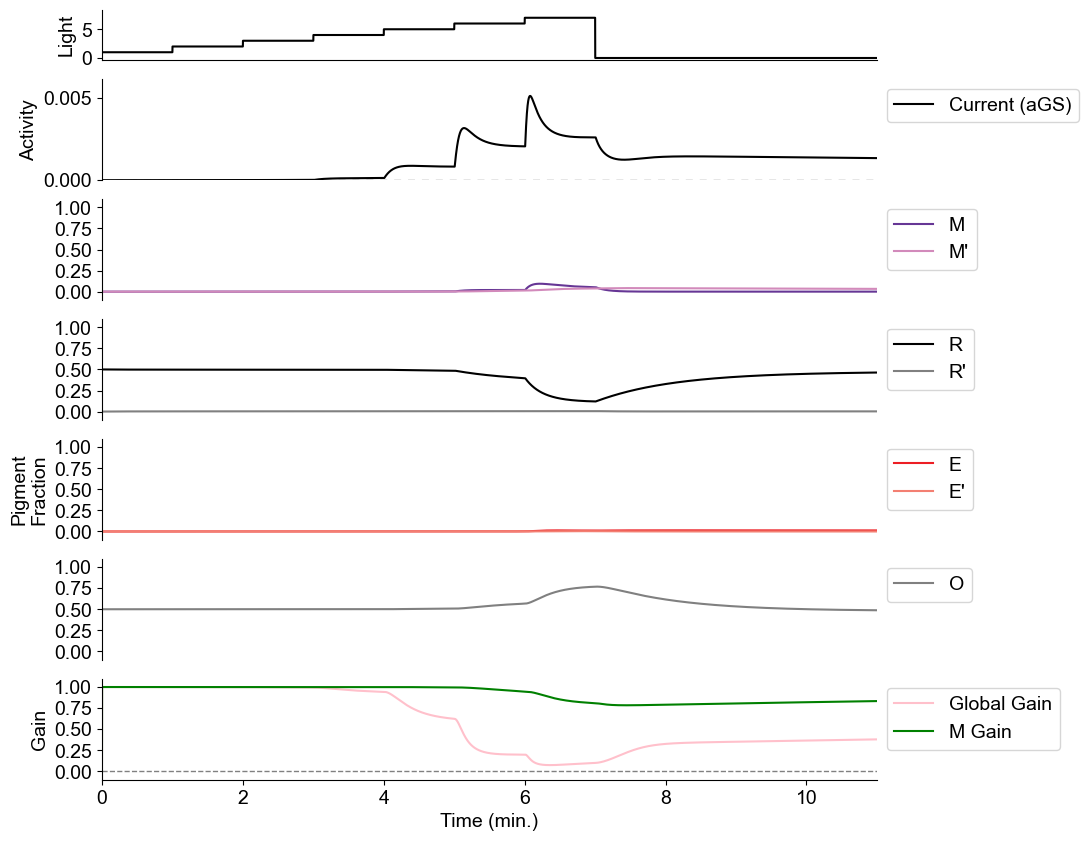

In [3]:
# Run the model on the light stimulus protocol
monochromatic_staircase_result = predictMelanopsin(monochromatic_staircase)

# Plot the results of the experiment
plot_model_run = plotModelRun(monochromatic_staircase_result)

## Broadband light

The workflow for using measured spectra requires several formatting steps. A few points bear extra emphasis:

❗
Stimuli must be formatted as **photon flux density** vs wavelength (photons/micron^2/s/nm) **NOT in terms of power** (e.g. uW/micron^2/nm). We provide a function called ```powerSpectrumToPhotonFlux``` that converts power spectra (uW/micron^2/nm) to intensity spectra (photons/micron^2/s/nm).

❗
The **spectra should be those that the melanopsin cells experience**. This requires compensating for any **prereceptoral filtering** in your system. In our study, we accounted for filtering by the mouse eye optics using a function ```inVivoTransmission``` that applies a published transmission curve (Henriksson et al. 2010) to light spectra measured outside the eye. Depending on your experimental configuration, you may have to account for additional forms of filtering, such as by animal cage materials. If you are interested in human melanopsin responses, consider eyeglasses and age-dependent changes in ocular lens transmission.

We follow this general workflow:
____________
1. Load spectral data into the notebook.
2. Re-*sample* spectra over a shared wavelength range (if using multiple spectra).
3. Convert from power to intensity.
4. Account for prereceptoral filtering.
5. Scale spectra to target intensities (if not already scaled as desired).
6. Build the light stimulus by inserting spectral data into the ```light_stim``` dictionary.
7. Run the model.
________________

### 1. Load spectral data

We will now prepare spectral data measured from a xenon lamp with and without a 560/10 nm bandpass filter.

The data sets are in the `Data` folder of the repository. They are saved as ```.txt``` and `.csv` files with one column called `wavelength` and the other `power`.

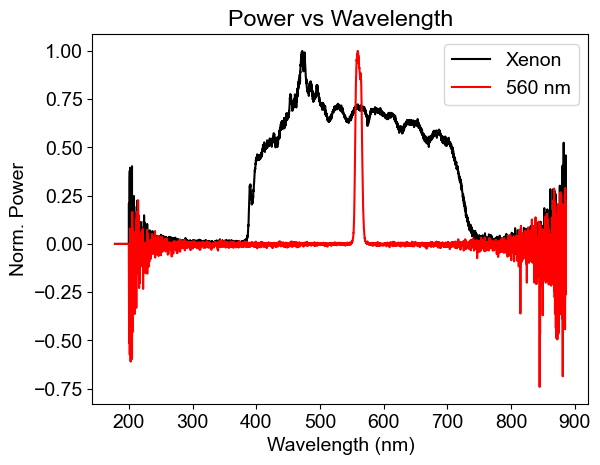

In [4]:
# Load xenon spectral data
dfxenon = pd.read_table(os.path.join(filepath, 'spectra', 'Xenon.txt'),  names=['wavelength', 'power'])
xenon_wlen = dfxenon["wavelength"] # Isolate wavelength data
xenon_power = dfxenon["power"] # Isolate power data

# Load 560/10 nm bandpass spectral data
df560 = pd.read_csv(r'./data/manuscript/spectra/560nm spectrum.csv')
spec560_wlen = df560["wavelength"].to_numpy() # TO DO: change all the data column names to 'wavelength'
spec560_power = df560["power"].to_numpy()

# Plot the spectra, normalizing for direct comparison
plt.plot(xenon_wlen, xenon_power / np.max(xenon_power), label='Xenon', color='k')
plt.plot(spec560_wlen, spec560_power / np.max(spec560_power), label='560 nm', color='r')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Norm. Power")
plt.title("Power vs Wavelength")
plt.legend()

### 2. Re-sample

Two potential problems exist with our input data. First, the spectrometer measurement is noisy at the edges of its wavelength range. We can safely trim these edges (melanopsin sensitivity is also low at these extremes). Second, different spectral datasets might not be sampled at identical wavelengths. We solve both problems using the ```imposeSpectrum()``` function. This function resamples (trims and interpolates) the data across wavelength values that we select. The arguments are the input spectrum power (e.g. `xenon_power`), the input wavelengths (e.g. `xenon_wlen`), and the desired standard wavelengths `specwlens`. If your data range is smaller than the selected range then the power will be zero outside the data range. If it is larger than your selected range, as is the case here, our function will trim the data to the new range.

Text(0.5, 1.0, 'Interpolated Power vs Wavelength')

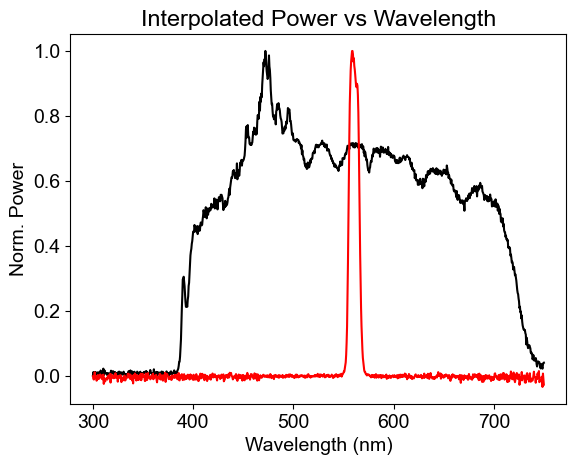

In [5]:
# Choose shared wavelengths
specwlen = np.linspace(300, 750, 1000) # Start, stop, number of samples

# Interpolate xenon spectrum to shared wavelengths
xenon_power = resampleSpectrum(xenon_power, xenon_wlen, specwlen)

# Interpolate 560 spectrum to shared wavelengths
spec560_power = resampleSpectrum(spec560_power, spec560_wlen, specwlen)

# Plot the interpolated and trimmed spectra
plt.plot(specwlen, xenon_power / np.max(xenon_power), label='Xenon', color='k')
plt.plot(specwlen, spec560_power / np.max(spec560_power), label='560 nm', color='r')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Norm. Power")
plt.title("Interpolated Power vs Wavelength")

### 3. Convert power to intensity

Convert from power to intensity using the ```powerSpectrumToPhotonFlux()``` function.

Text(0.5, 1.0, 'Intensity vs Wavelength')

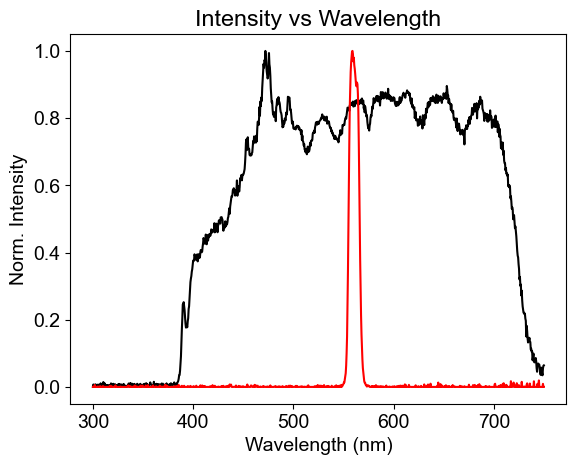

In [6]:
# Convert power spectra to intensity spectra
xenon_intensity = np.array(powerSpectrumToPhotonFlux(xenon_power, specwlen))
spec560_intensity = np.array(powerSpectrumToPhotonFlux(spec560_power, specwlen))


# Plot the intensity spectra
plt.plot(specwlen, xenon_intensity / np.max(xenon_intensity), label='Xenon', color='k')
plt.plot(specwlen, spec560_intensity / np.max(spec560_intensity), label='560 nm', color='r')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Norm. Intensity")
plt.title("Intensity vs Wavelength")

### 4. Pre-receptoral filtering

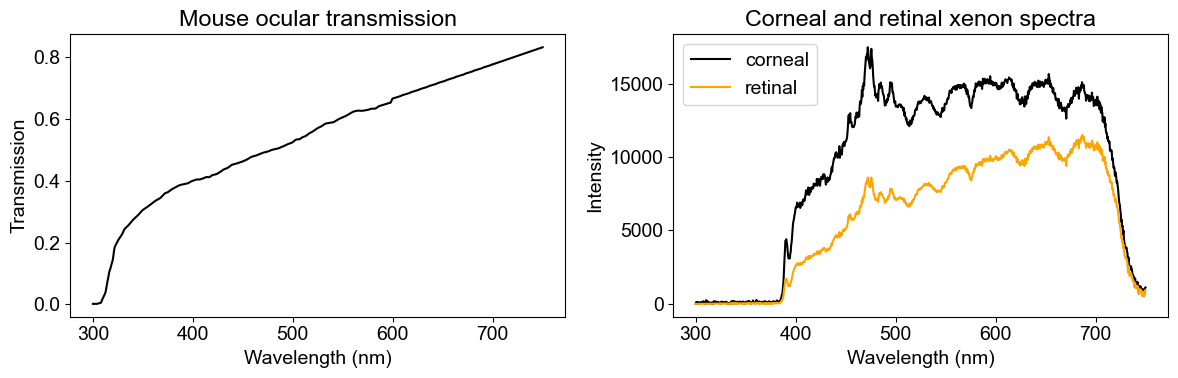

In [7]:
# Save the corneal intensity for comparison
xenon_intensity_corneal = xenon_intensity
spec560_intensity_corneal = spec560_intensity

# Mouse ocular filter transmission
eye_transmission = pd.read_csv(os.path.join(filepath, 'spectra', 'mouse cornea and lens transmission.csv'))
transmission_wlen = eye_transmission["wlen"].to_numpy()
transmission = eye_transmission["transmission"].to_numpy()

# Apply transmission filter
xenon_intensity_retinal, transmission_interp = inVivoTransmission(
    specwlen, xenon_intensity, transmission_wlen, transmission
)
spec560_intensity_retinal, _ = inVivoTransmission(
    specwlen, spec560_intensity, transmission_wlen, transmission
)

# Create side-by-side plots (transmission on LEFT, spectra on RIGHT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Left: interpolated transmission only
ax1.plot(specwlen, transmission_interp, color='k')
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Transmission")
ax1.set_title("Mouse ocular transmission")

# Right: spectra before vs after filtering
ax2.plot(specwlen, xenon_intensity_corneal, label='corneal', color='k')
ax2.plot(specwlen, xenon_intensity_retinal, label='retinal', color='orange')
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("Intensity")
ax2.set_title("Corneal and retinal xenon spectra")
ax2.legend()

plt.tight_layout()
plt.show()

### 5. Scale spectra to target intensities (optional)

—You can skip this step if you have spectral measurements of your light stimulus at all the intensities you desire to model—

In practice, we often scale spectral data measured at one light intensity to several target intensities. We find two methods useful for specifying the intensity of broadband spectra and provide functions for each:   

1. Photon count. The `scaleToPhotonCount` function scales your intensity spectrum such that its integrated photon count equals a target value.

2. Melanopsin-equivalent photons. The `scaleToEquivalentPhotons` function scales your intensity spectrum such that it produces the same activation of melanopsin's ground state (R) as a target number of monochromatic photons (at a wavelength of your choosing (sepcified by the `wlen_match` argument), often selected near the R state's peak spectral sensitivity at 467 nm).    

Both functions accept `spec_wlen` and `spec_intensities` arguments as well as a list of `intensities` (photon count or melanopsin-equivalent photons for each stimulus interval). The functions return two arrays of arrays (`spec_wlens` and `xenon_specints_scaled` in the example below). Each element of `spec_wlens` and `xenon_specints_scaled` specifies a scaled spectrum for each stimulus interval. In the example below we scale the xenon spectrum to seven different target intensities, specified as 440-nm equivalent photons.

In [8]:
# Specify target intensities in terms of melanopsin-equivalent 440 nm photons
intensities_440eqiv = np.array([10**1, 10**2, 10**3, 10**4, 10**5, 10**6, 10**7]) # 7 stimulus intervals

# Produce a scaled xenon spectral intensity for each stimulus interval
specwlens, xenon_specints_scaled = scaleToEquivalentPhotons(specwlen, xenon_intensity, intensities_440eqiv, wlen_match=440)

### 6. Build the light stimulus

In [9]:
# Create a dictionary in which to specify the light stimulus
spec_staircase = {}

# Duration of the experiment, in seconds
spec_staircase['ti'] = 660

# Start and stop time for each stimulus interval
spec_staircase['timings'] = [0,60, 60,120, 120,180, 180,240, 240,300, 300,360, 360,420]

# A spectral intensity for each stimulus interval
spec_staircase['intensities'] = xenon_specints_scaled

# wavelength range for the spectrum in each stimulus interval
spec_staircase['wlen'] = specwlens

### 7. Run the model

The Main Loop:   0%|          | 0/65999 [00:00<?, ?it/s]

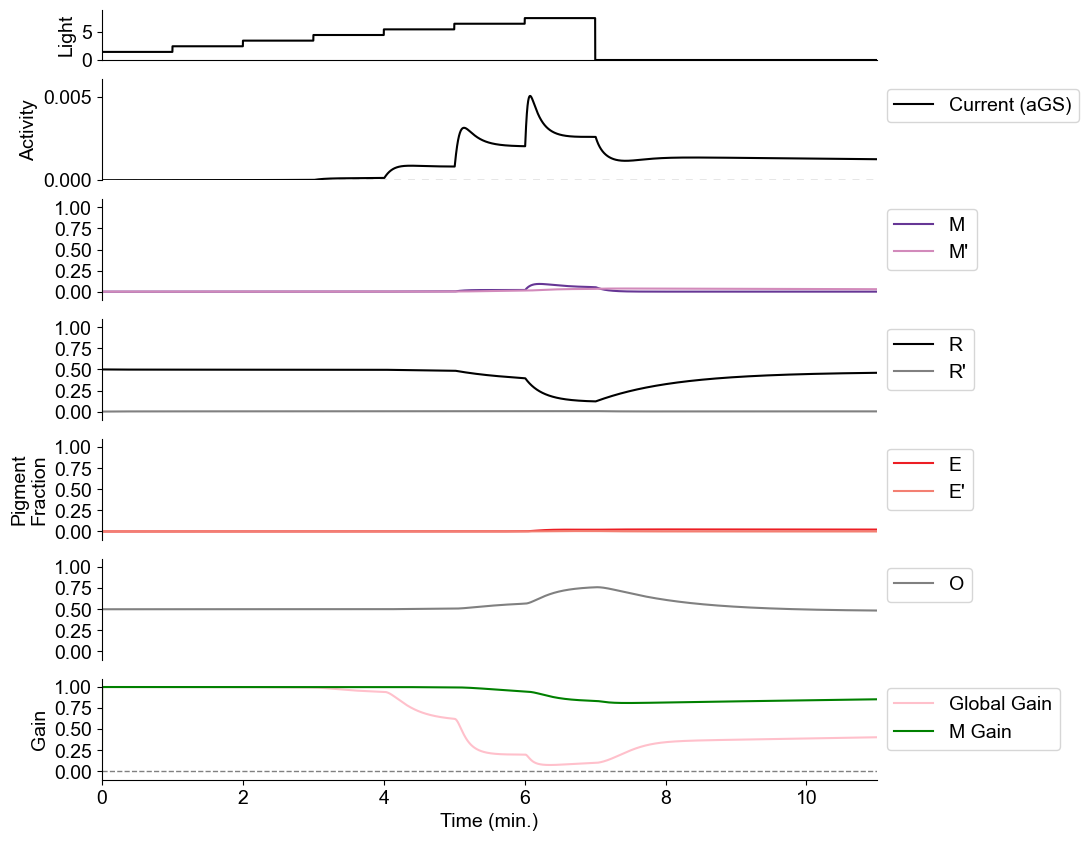

In [10]:
# Run the model on the spectral staircase light stimulus
spec_staircase_result = predictMelanopsin(spec_staircase)

# Plot results
spec_staircase_fig = plotModelRun(spec_staircase_result)

## Combining multiple spectra

To further explore stimulus protocol design, let's extend the spectral staircase example by adding a stimulus interval with a different light spectrum. Earlier we loaded and formatted a spectrum measured from a xenon lamp fitted with a 560/10 nm bandpass filter. Let's add a stimulus interval after the xenon staircase containing this 560/10 nm spectrum.

In [11]:
### Scale the 560 nm spectrum ###

# Specify the target intensity
target_intensity = [10**9] # Target intensity

# Scale the 560 spectrum (this time we use photon count instead of melanopsin-equivalent photons)
spec560_wlens, spec560_intensity_scaled = scaleToPhotonCount(specwlen, spec560_intensity, target_intensity)


### Add the new spectrum to the xenon staircase stimulus ###

# Create a new dictionary to specify the light stimulus protocol, starting with values from spec_staircase
spec_staircase_ext_560 = {}

# Update duration
spec_staircase_ext_560['ti'] = 780

# Append a new interval to timings using np.append
spec_staircase_ext_560['timings'] = np.append(spec_staircase['timings'], [480, 540])

# Append the new spectral intensity array using np.vstack
spec_staircase_ext_560['intensities'] = np.vstack((spec_staircase['intensities'], spec560_intensity_scaled))

# Append a new wavelength array using np.vstack
spec_staircase_ext_560['wlen'] = np.vstack((spec_staircase['wlen'], spec560_wlens))

The last stimulus interval now contains the appropriately scaled 560/10 nm spectrum.

/tmp/ipykernel_166/160496568.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  photon_count = np.trapz(intensity, wlen)


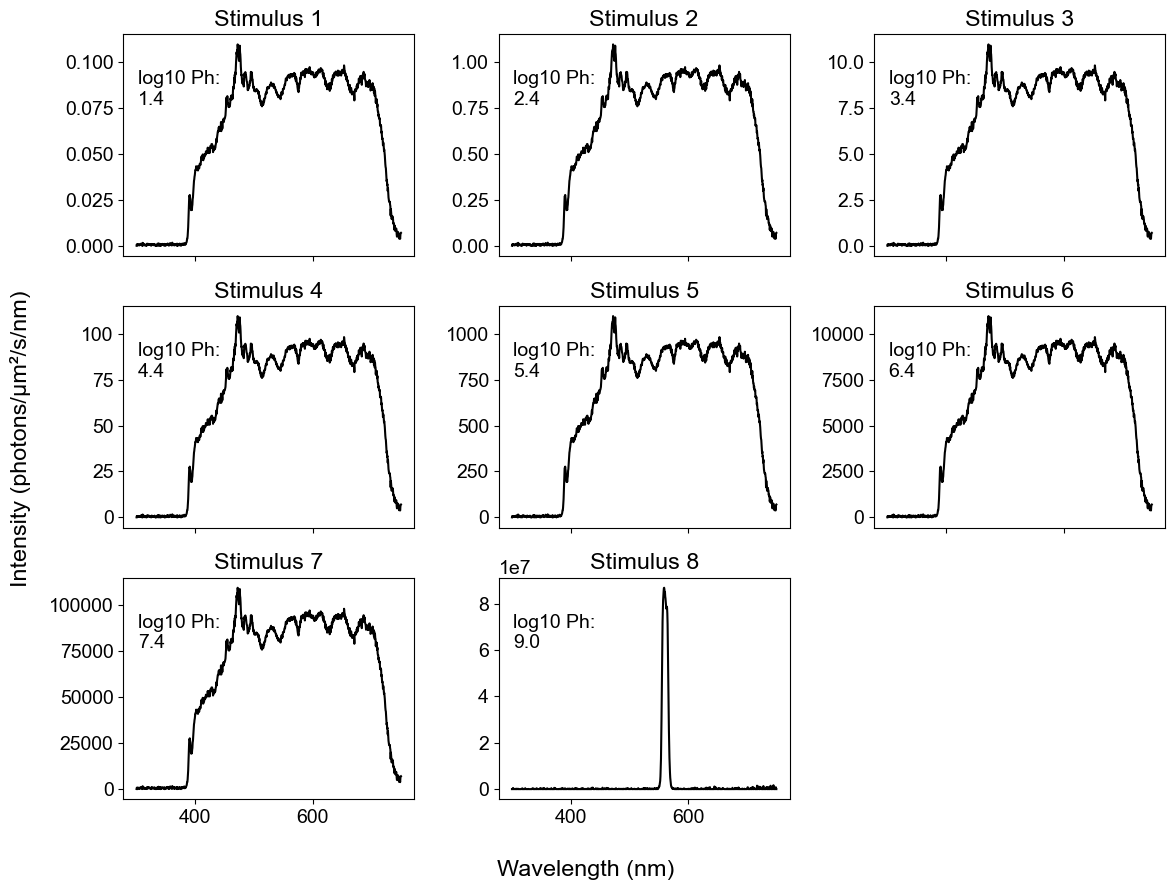

In [12]:
# Number of stimuli
n = len(spec_staircase_ext_560['wlen'])

# Choose subplot grid automatically (square layout)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=False)
axes = axes.flatten()  # makes indexing easy

for i in range(n):
    ax = axes[i]

    wlen = spec_staircase_ext_560['wlen'][i]
    intensity = spec_staircase_ext_560['intensities'][i]

    # Plot spectrum
    ax.plot(wlen, intensity, 'k')

    # Photon count via numerical integration
    photon_count = np.trapz(intensity, wlen)

    # Annotate photon count
    ax.annotate(
        f'log10 Ph:\n{np.log10(photon_count):.1f}',
        xy=(0.05, 0.75),
        xycoords='axes fraction',
        ha='left',
        va='center'
    )

    ax.set_title(f'Stimulus {i+1}')

# Axis labels only on outer edges
for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel("Wavelength (nm)")
fig.supylabel("Intensity (photons/µm²/s/nm)")

plt.tight_layout()
plt.show()

Run the model on the xenon staircase with the 560 nm stimulus.

The Main Loop:   0%|          | 0/77999 [00:00<?, ?it/s]

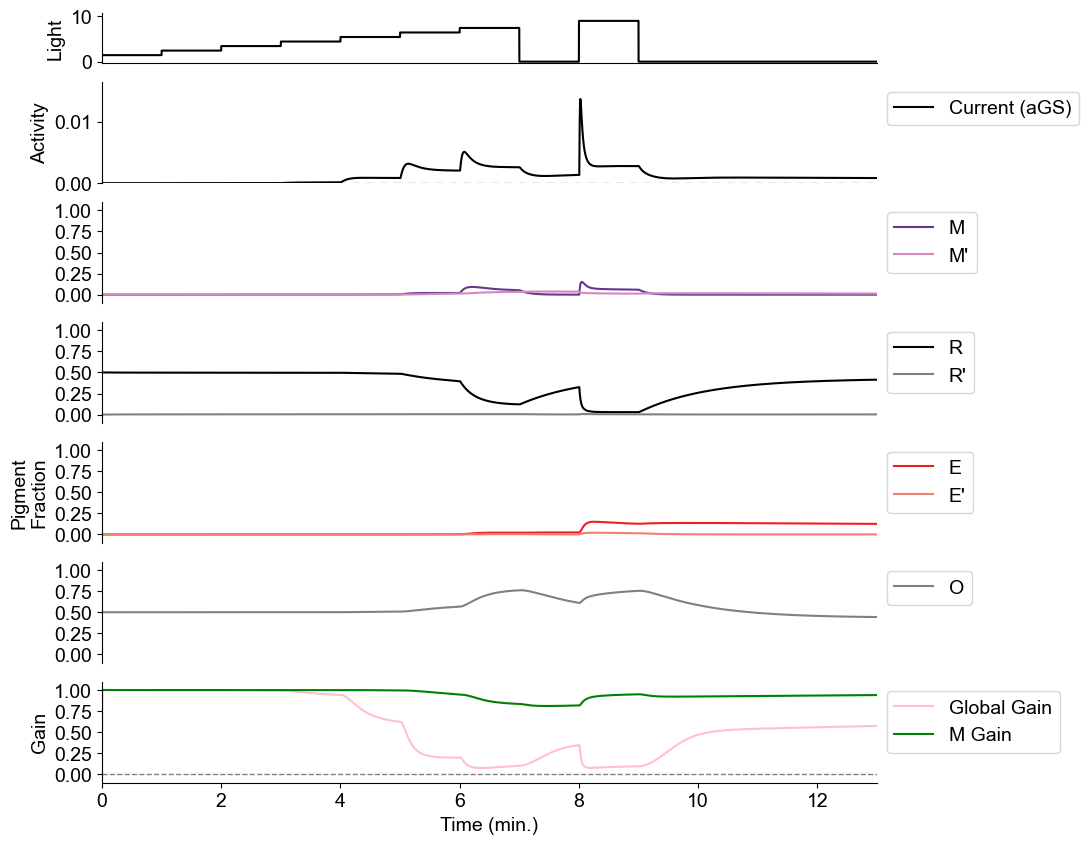

In [13]:
# Run the model
spec_staircase_ext_560_result = predictMelanopsin(spec_staircase_ext_560)

# Plot the result
spec_staircase_ext_560_fig = plotModelRun(spec_staircase_ext_560_result)

To compare model outputs with and without the 560 nm light, we run a longer simulation on the original xenon staircase.

The Main Loop:   0%|          | 0/77999 [00:00<?, ?it/s]

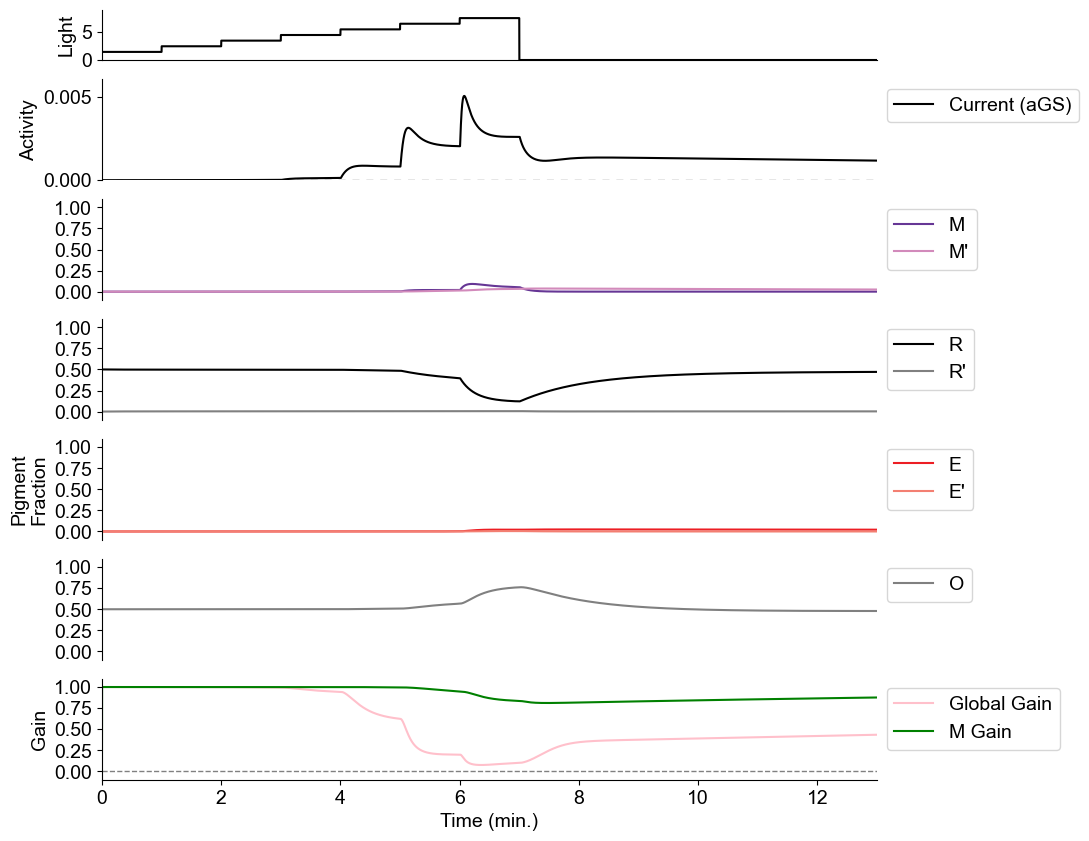

In [14]:
# Copy the xenon staircase stimulus
spec_staircase_ext = spec_staircase

# Adust the simulation time so it's equivalent to the staircase with the 560 nm interval
spec_staircase_ext['ti'] = spec_staircase_ext_560['ti']

# Run the model for an extended time on the xenon staircase stimulus
spec_staircase_ext_result = predictMelanopsin(spec_staircase_ext)

# Plot the result
spec_staircase_ext_fig = plotModelRun(spec_staircase_ext_result)

We provide a list of model result dictionaries to the `overlayModelActivity` function and it overlays the predictions; Note in the orange trace the lower level of persistent activity after the 560 nm pulse .

(-0.001, 0.006)

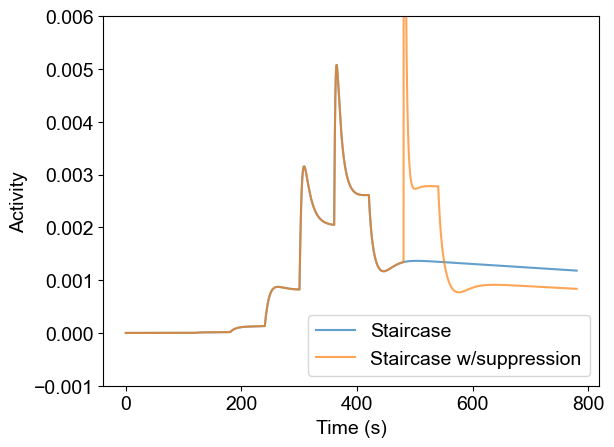

In [15]:
fig = overlayModelActivity([spec_staircase_ext_result, spec_staircase_ext_560_result],
                     labels=['Staircase', 'Staircase w/suppression'])

# Get all axes objects from the figure
axes = fig.get_axes()

# set y-limits to focus on persistent activity
axes[0].set_ylim([-0.001, 0.006])

# **Appendix**

We provide details of model inputs and outputs and a primer on modfiying parameters. Predictions from our manuscript are also reproduced here.

## Model outputs

`predictMelanopsin` returns a **dictionary** of `key, value` pairs. This dictionary contains the model **parameters**, a copy of the **light stimulus protocol**, and the model **predictions**. The model predictions are arrays with length = simulation duration / time step.

The most important outputs are accessed as follows:

```
results_dict['xaxis'] # Timebase, in seconds

results_dict['currentGlobalGain'] # Activity

results_dict['R'] # Fraction in R state
results_dict['M'] #          ...M state
results_dict['E'] #          ...E state

results_dict['Rprime'] # Fraction in low gain R state
results_dict['Mprime'] #                  ... M state
results_dict['Eprime'] #                  ... E state

results_dict['O'] # Fraction in O state

results_dict['gg_scalar'] # Global gain
results_dict['mg_scalar'] # M gain

results_dict['params'] # Model parameters
```

Below we print out the keys and values from the previous simulation's output dictionary (the xenon staircase - 560/10 nm light stimulus)

In [16]:
# Inspect the model output dictionary from the xenon + 560 staircase
for key, value in spec_staircase_ext_560_result.items():
    if hasattr(value, "shape"):
        print(f"{key:<25} shape={value.shape}  dtype={value.dtype}")
    else:
        print(f"{key:<25} {value}")

xaxis                     shape=(78000,)  dtype=float64
R                         shape=(78000,)  dtype=float64
M                         shape=(78000,)  dtype=float64
E                         shape=(78000,)  dtype=float64
O                         shape=(78000,)  dtype=float64
Rprime                    shape=(78000,)  dtype=float64
Mprime                    shape=(78000,)  dtype=float64
Eprime                    shape=(78000,)  dtype=float64
gg                        shape=(78000,)  dtype=float64
mg                        shape=(78000,)  dtype=float64
gg_scalar                 shape=(78000,)  dtype=float64
mg_scalar                 shape=(78000,)  dtype=float64
currentOut                shape=(78000,)  dtype=float64
currentNoLowGain          shape=(78000,)  dtype=float64
currentGlobalGain         shape=(78000,)  dtype=float64
lightIntensity            shape=(78000, 8)  dtype=float64
lightWavelength           shape=(78000, 8)  dtype=float64
stimMonitor               shape=(78000,)  dt

## Model parameters

To modify internal model parameters, use the optional `config` argument:  `predictMelanopsin(config=your_config)`.`your_config` must be a **dictionary**. The model merges `your_config` with its default parameter dictionary, overwriting when your entries overlap with defaults. In other words, **you only need to provide dictionary entries for parameters you wish to change**. Here are the `key: value` pairs in the model's default parameter set. Spectral sensitivity parameters are described in a dedicated section below.

```
# Simulation time step, seconds
rate: 0.01 # Well-converged at this rate but will eventually diverge and become unstable at higher rates.

# Toggle forms of negative feedback
activity feedback: True
Mprime feedback: True

# Quantum efficiencies
Rphi: 0.52
Mphi: 0.22
Ephi: 0.65

# Extinction coefficients
Reps: 33,000,000
Meps: 52,600,000
Eeps: 42,000,000

# Probability of M transitioning to E. M to R transition is 1-propME.
propME: 0.5

# Rate constants governing spontaneous transitions between high and low gain states (s^-1)
konM: 0.012  # M to M'
koffM: 0.0012  # M' to M

konR: 1/3600  # R to R'
koffR: 0.0454545  # R' to R

konE: 1/3600  # E to E'
koffE: 0.0454545  # E' to E

# Controls scaling of konM depending on M' fraction
m deplete thresh: 0.05
m deplete scalar: 2.0

# Rate constants for leaky integration in negative feedback (s^-1)
konMG: 1.0
koffMG: 0.355

konGG: 1.0
koffGG: 0.037

# Nonlinearities for negative feedback
k_mg: 1.215 # steepness for M'-driven negative feedback
x0_mg: 0.381 # inflection point for M'-driven negative feedback

k: 40 # steepness for activity-driven negative feedback
L: 1.0 # upper asymptote
x0: 8e-4 # inflection point

# Signaling gain
MprimeGain: 0.2
Ogain: 3.16e-7

# Bleaching rate constants (s^-1)
kbleachR: 0.75e-2 # R to O
kbleachRprime: 0.75e-2
kbleachM: 1e-1
kbleachMprime: 1e-4
kbleachE: 5e-4
kbleachEprime: 1e-4
koffO: 0.75e-2 # O to R

# Thermal decay of M (s^-1). Inactive in the current setup (kthermM = 0).
# Experimental feature intended for exploration and future development.
kthermM: 0.0  # off
propMEtherm: 0.5  # given a thermal transition of M, probability it goes to E rather than R

```
Some parameters in the model are well-constrained by published biochemical measurements. Others have not yet been defined experimentally and values are based on related literature or fits to electrical responses recorded from melanopsin neurons. Anticipating future experimental work, we provide examples below that show how to adjust some of the parameters whose values are currently uncertain.  

### E state Quantum efficiency

The quantum efficiency (QE) of the E state is unknown. Matsuyama and colleagues measured QE for R and M (0.52 and 0.22, respectively). We found that a higher value for E's QE improved our model fits, particularly when predicting responses to broadband xenon light. Below we load a xenon stimulus (with ocular filtering simulated by an optical filter). We compare model predictions with our default E QE of 0.65 and a reduced QE of 0.4.

`E_lowQE_config = {'Ephi': 0.4} ` replaces the default value of Ephi in the model's internal configuration dictionary.

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

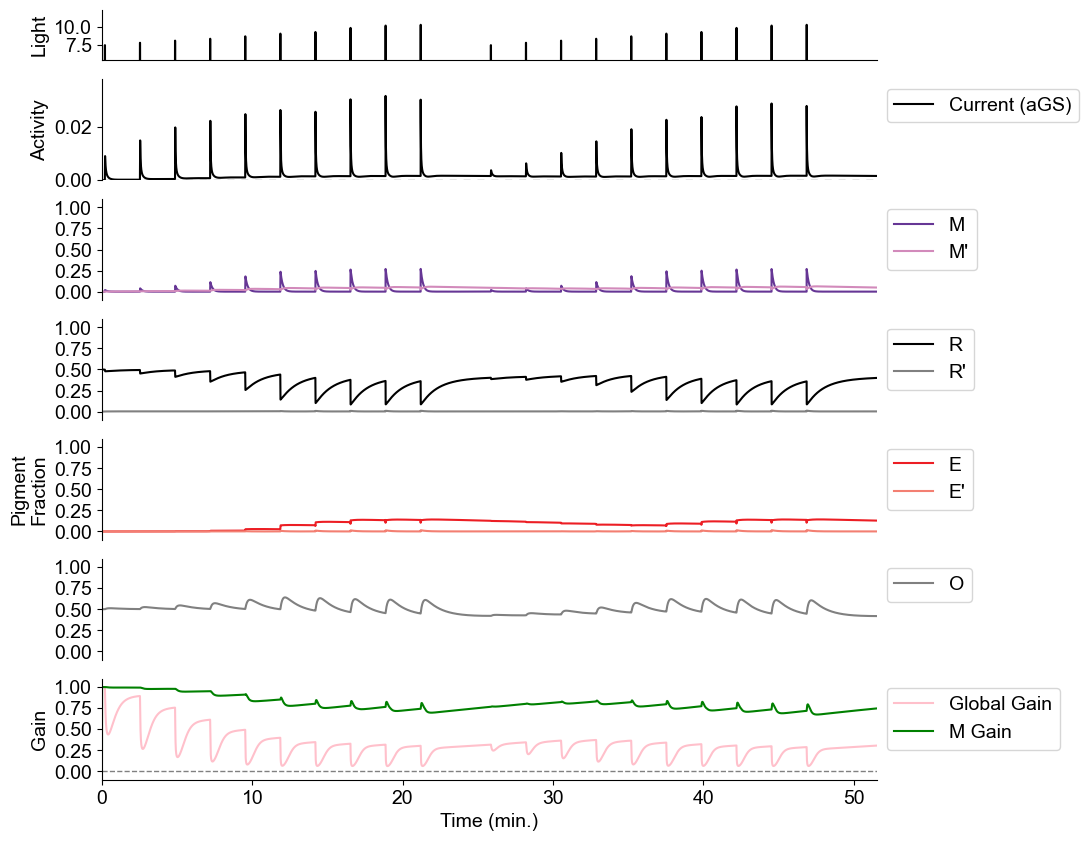

In [17]:
# Create a configuration dictionary that sets Ephi to a new value
E_lowQE_config = {'Ephi': 0.4} # default value is 0.65

# Load a xenon stimulus with simulated ocular filtering (see study for details)
stimXenonEye = setupModelRun("intensity response", "xenon eye", rate = 0.005, specwlen=wlenshared, specint=xenon_eye['photons'])

# Run the model, passing in the light stimulus protocol and configuration dictionary
xenon_eye_low_E_QE_result = predictMelanopsin(stimXenonEye, config=E_lowQE_config)

# Plot the result
E_lowQE_fig = plotModelRun(xenon_eye_low_E_QE_result)

For comparison, run the model on the same light stimulus with E QE set to the default value (0.65).


The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

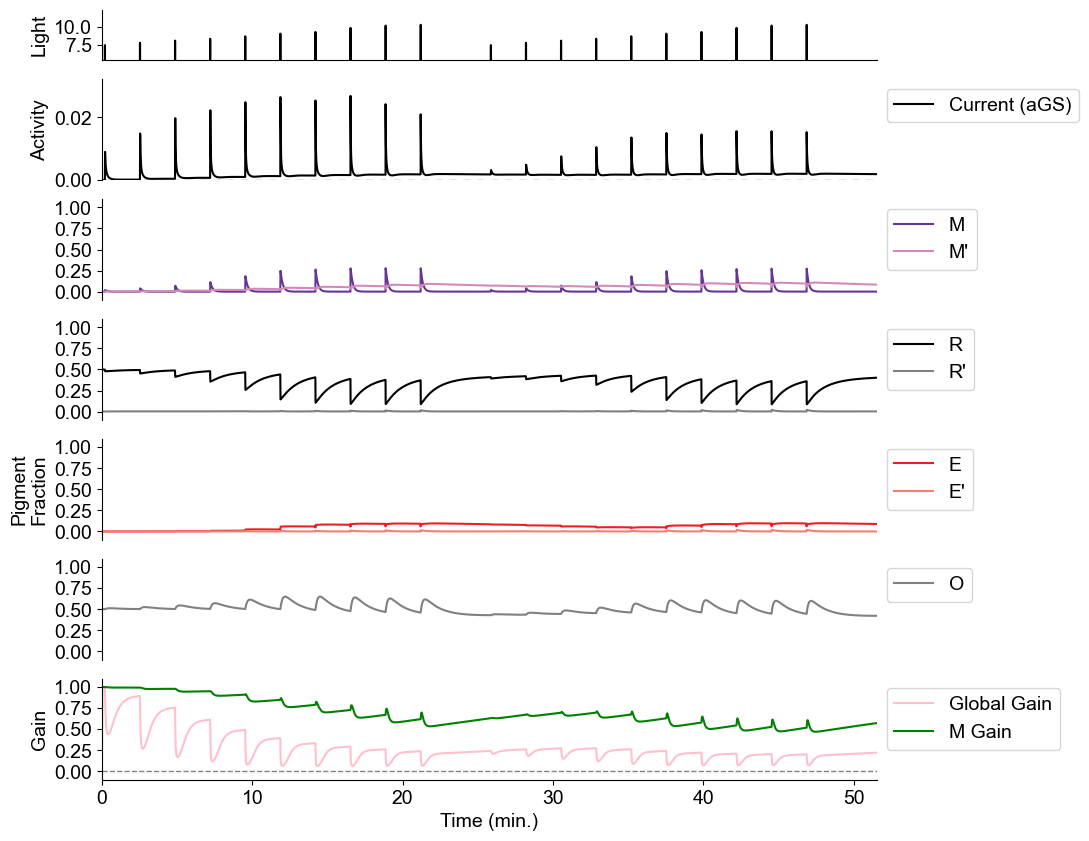

In [18]:
xenon_eye_result = predictMelanopsin(stimXenonEye)

xenon_eye_fig = plotModelRun(xenon_eye_result)

Note that E's QE substantially changes the model prediction, especially after light history accumulates. Higher E QE results in more persistent activity and stronger negative feedback that reduces transient response amplitude—closely resembling responses to this stimulus in melanopsin cells.

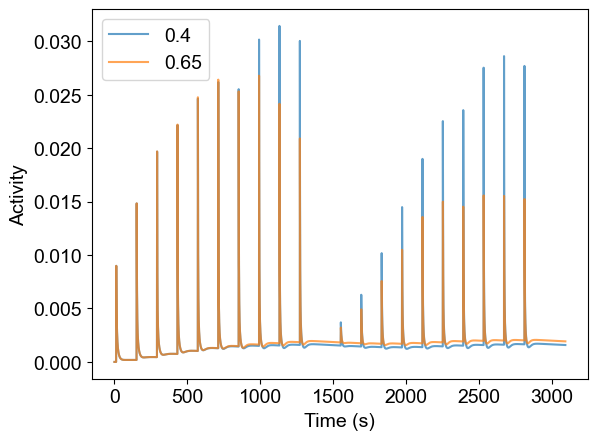

In [19]:
# Overlay model activity produced with low and default E QE
h_E_QE = overlayModelActivity([xenon_eye_low_E_QE_result, xenon_eye_result], labels=['0.4', '0.65'])

### Spectral Sensitivity

By default, the model uses spectral templates based on the equations of Govardovskii (Govardovskii 2000), with parameters in some cases adjusted for better agreement with published measurements of melanopsin's spectral sensitivity:

**R:** photochemical measurements of purified melanopsin (Matsuyama et al. 2012) and action spectra recorded from melanopsin cells in our lab (Emanuel and Do 2015)

**M:** photochemical measurements of purified melanopsin (Matsuyama et al. 2012)

**E:** no published spectral tempate for melanopsin in a pure E state; we default to the standard Govardovskii template

 Below we list the parameters that control the shape of each state's spectral template. Note that when parameters depart from Govardovskii's the true peak spectral sensitivity `true_lambda_max` differs from the `lambda_max_param`.

 Setting the `spectral sensitivity` parameter to 'Govardovskii' switches all the templates to the standard Govardovskii template in which `true_lambda_max` is the only free parameter.


        spectral sensitivity: 'Custom' # 'Custom' or 'Govardovskii'

        # R state nomogram. Fit to ground state action spectrum (Emanuel and Do 2015)
        'R_true_lambda_max': 467
        'R_lambda_max_param': 494
        'R_A': 44.582569987408945
        'R_B': 8.614863087478009
        'R_C': -11.594413782436712
        'R_D': 0.0
        'R_a': 0.9324464256209672
        'R_b': 0.9901137601105081
        'R_c': 1.128289328759767

        # M state nomogram (Matsuyama et al. 2012)
        'M_true_lambda_max': 476
        'M_lambda_max_param': 483.0
        'M_A': 44.402
        'M_B': 11.768
        'M_C': -14.088
        'M_D': 0.2554
        'M_a': 0.90595
        'M_b': 0.87117
        'M_c': 1.1367

        # E state nomogram (Govardovskii 2000)
        'E_true_lambda_max': 446
        'E_lambda_max_param': 446
        'E_A': 69.7
        'E_B': 28
        'E_C': -14.9
        'E_D': 0.674
        'E_a': 0.8795 + 0.0459 * np.exp(-(446-300)**2 / 11940)
        'E_b': 0.922
        'E_c': 1.104

How do model predictions change if we switch to Govardovskii spectral templates for all states? Below we change the configuration dictionary so the model uses Govardovskii templates for all states, then run the model on ocular- filtered xenon light.

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

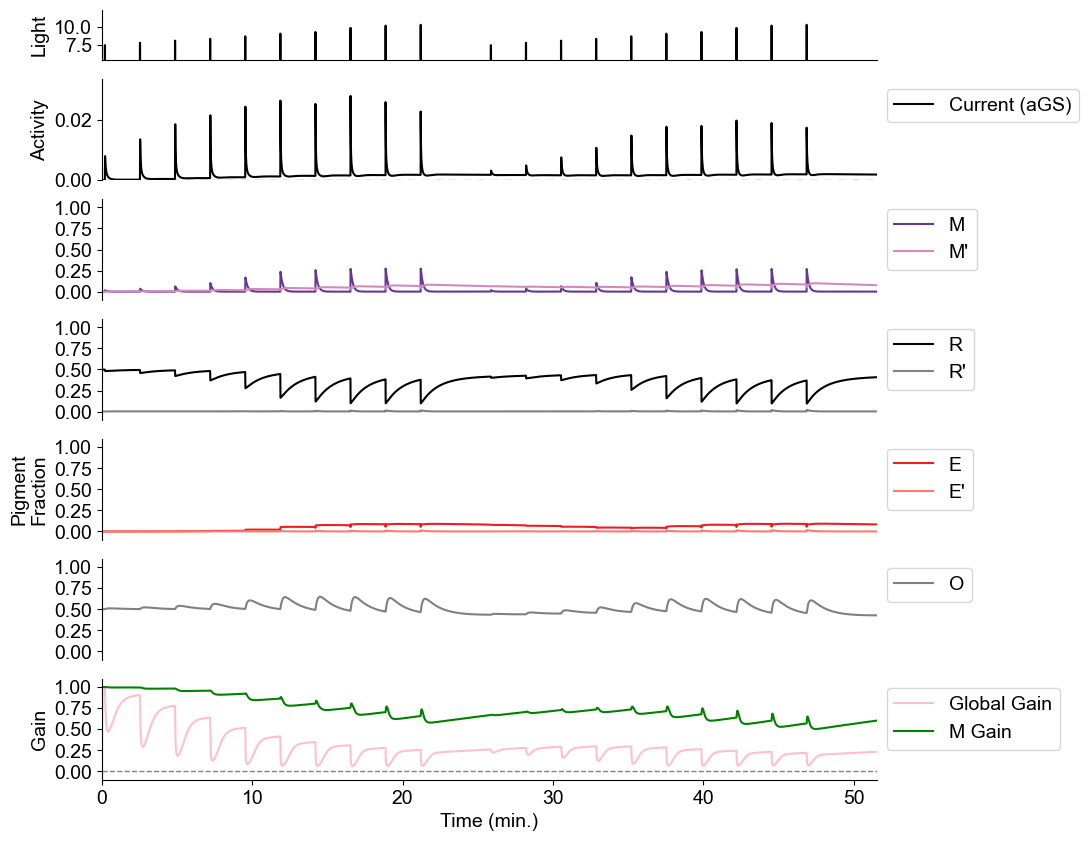

In [20]:
# Configuration dictionary
gov_config = {'spectral sensitivity': 'Govardovskii'}

# Run model on the ocular-filtered xenon
gov_result = predictMelanopsin(stimXenonEye, config=gov_config)

# Plot the result
gov_fig = plotModelRun(gov_result)

Earlier we ran the default model on the ocular-filtered xenon stimulus. Overlaying the prediction obtained with Govardovskii spectral templates reveals a relatively small difference. Govardovskii templates predict incrementally less persistent activity and adaptation.

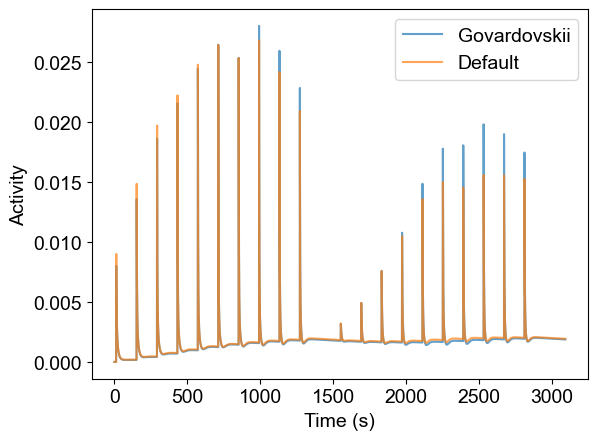

In [21]:
h_gov_default = overlayModelActivity([gov_result, xenon_eye_result], labels=['Govardovskii', 'Default'])

The `plotSpectralTemplates` function allows us to visualize the spectral templates. Pass the function a list of configuration dictionaries that include the spectral templates you wish to plot. In the example below, these are `[params_R, params_M, params_E]`, which we pair with an optional parameter `RME_colors` to set the color of each template in the plot. Set the optional `logy` parameter to `True` to swap to a logarithmic y axis.  

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Spectral Templates'}, xlabel='Wavelength (nm)', ylabel='Normalized spectral sensitivity'>)

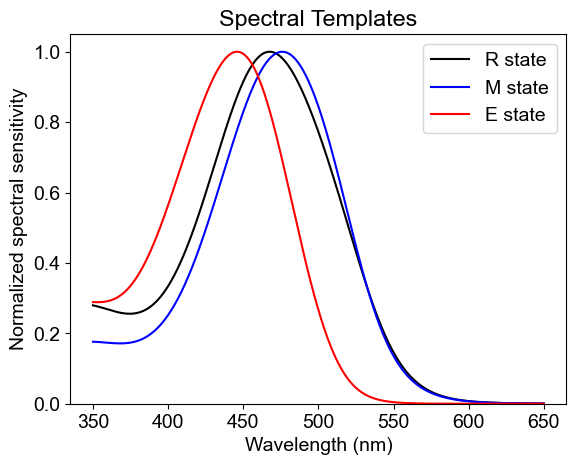

In [22]:
## Extract the model's default parameters
default_params = xenon_eye_result['params']

# Extract parameters for a particular state's spectral template
params_R = getNomogramParams(default_params, 'R')
params_M = getNomogramParams(default_params, 'M')
params_E = getNomogramParams(default_params, 'E')

# Specify colors for plotting R, M, and E templates
RME_colors = ['k', 'b', 'r']

# Plots the spectral templates
plotSpectralTemplates(
    [params_R, params_M, params_E],
    labels=["R state", "M state", "E state"],
    colors=RME_colors
)

We can also make more granular changes to spectral template shapes. To demonstrate, let's change the R spectral template to one reported for purified melanopsin (Matsuyama 2012).

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Spectral Templates'}, xlabel='Wavelength (nm)', ylabel='Normalized spectral sensitivity'>)

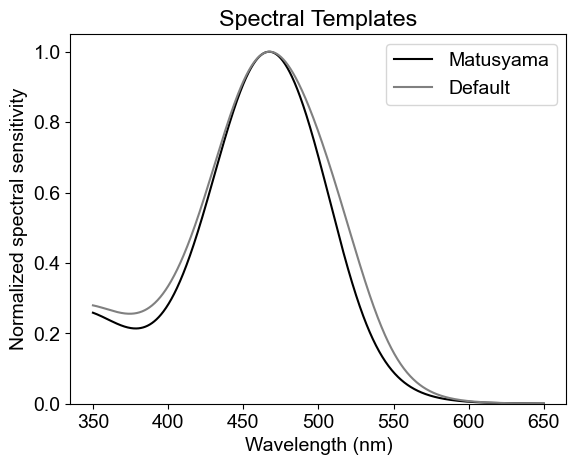

In [23]:
# Create configuration dictionary
R_Matsuyama_config = {
      'R_true_lambda_max': 467,
      'R_lambda_max_param': 476.62,
      'R_A': 41.047,
      'R_B': 12.679,
      'R_C': -15.768,
      'R_D': 0.45454,
      'R_a': 0.91961,
      'R_b': 0.91671,
      'R_c': 1.1055
      }

# Transform the dictionary into a form suitable for plotting (removes the 'R_' from keys)
params_R_Matsuyama = getNomogramParams(R_Matsuyama_config, 'R')

# Plot the Masuyama 2012 spectral template for R alongside our default
plotSpectralTemplates([params_R_Matsuyama, params_R],
                      labels=["Matusyama", "Default"],
                      colors= ['k', 'grey'])

Running the model with the modified R spectral template (Matsuyama 2012) on the ocular-filtered xenon stimulus  

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

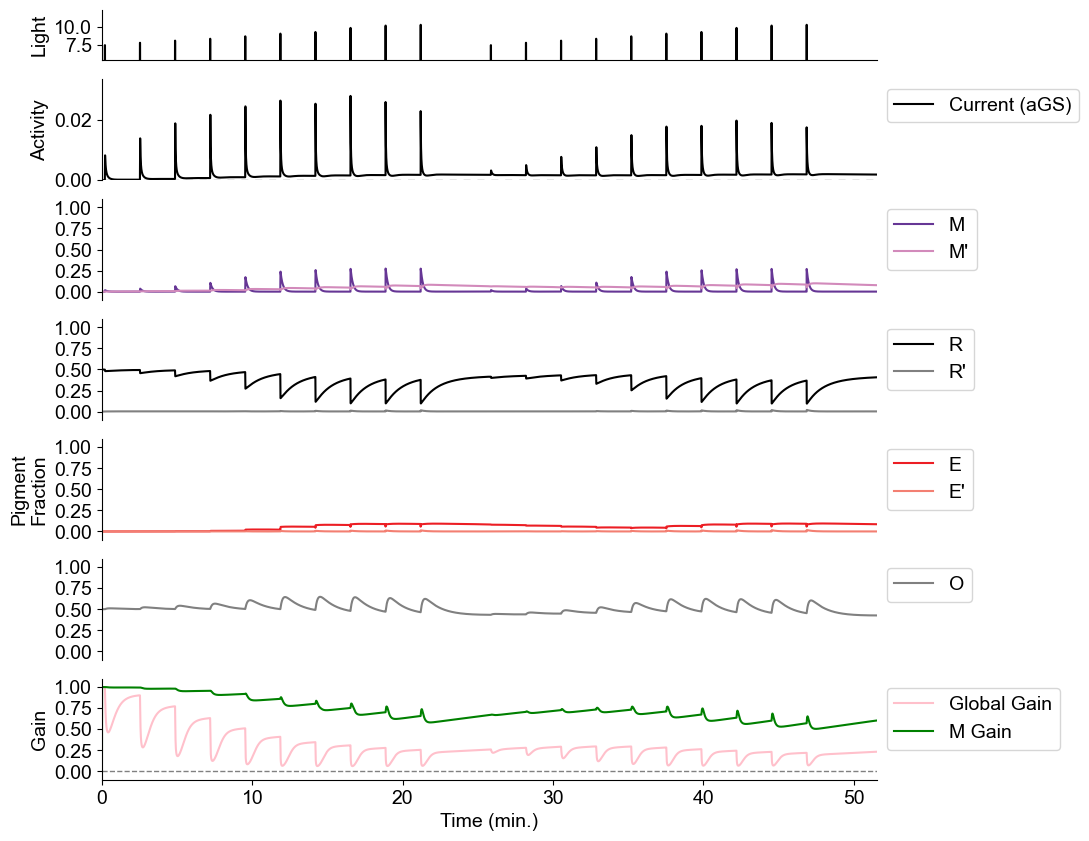

In [24]:
# Run model on the ocular-filtered xenon using the Matsuyama 2012 R template
R_Matsuyama_result = predictMelanopsin(stimXenonEye, config=R_Matsuyama_config)

# Plot the result
R_Matsuyama_fig = plotModelRun(R_Matsuyama_result)

Overlaying the prediction we just generated above with the prediction of the default model:

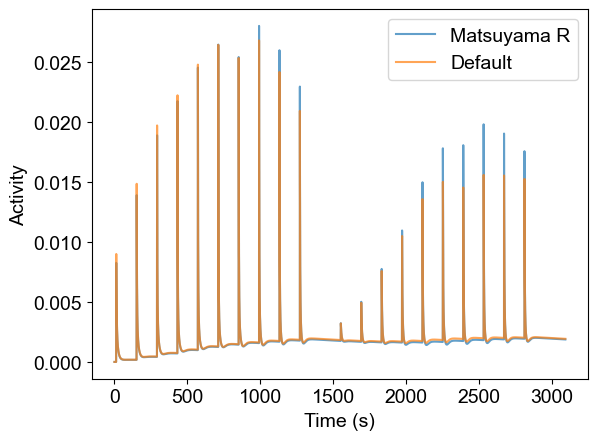

In [25]:
# Overlay model activity
h_RMatsuyama_default = overlayModelActivity([R_Matsuyama_result, xenon_eye_result],
                                            labels=['Matsuyama R', 'Default'])

### Active negative feedback

There are two forms of active negative feedback in the model that correspond to two scalar values (`gg_scalar` and `mg_scalar`); these affect how activity is determined from the fraction of melanopsin in signaling states:

$$ activity = gg_{scalar} * (M*mg_{scalar} + M'*M'_{Gain})$$

Two distinct mechanisms adjust the values of `gg_scalar` and `mg_scalar`:
1) Activity suppresses signaling from the M and M' states. This reduces the `gg_scalar` ('global gain scalar') variable.  
2) M' suppresses signaling from the M state. This reduces the `mg_scalar` ('M gain scalar') variable.


Each negative feedback mechanism acts through three steps:
1) A feedback signal accumulates (e.g., from activity, referred to in the model as `currentGlobalGain`) according to a rate constant (e.g. `konGG`)
2) The same feedback signal also passively decays at every timestep according to a rate constant (e.g., `koffGG`).
3) The feedback signal passes through a nonlinearity (see below) to determine the gain (e.g.,`gg_scalar`)

To determine `mg_scalar`, the nonlinearity is based on the Weibull distribution (one minus the cumulative distribution function)
$$mg_{scalar}(x)=e^{\left(\frac{-x}{x_0}\right)^k}$$
where $x_0$ sets the position of the inflection point and $k$ controls the steepness of the curve.

To determine `gg_scalar`, we use the logistic function
$$
gg_{scalar}(x) = \frac{1}{1+e^{-k(x-x_0)}}
$$
where $x_0$ is the position of the inflection point and $k$ controls the steepness.

The range of both nonlinearities is the interval $gg_{scalar}(x), mg_{scalar}(x)\in[0,1]$.

Interactive graphs for both functions are provided below to show how each changes with its parameters.

In [26]:
# Interactive plot of M gain nonlinearity
interact(plotWeib, k=(0,100, 0.01), x0=(0,1,0.01))

interactive(children=(FloatSlider(value=1.215, description='k', step=0.01), FloatSlider(value=0.381, descripti…

<function myutils.plotting_functions.plotWeib(k=1.215, x0=0.381)>

In [27]:
# Interactive plot of global gain nonlinearity
interact(plotSigmoid, k=(0, 100, 0.01), x0=(0, 1, 0.01))

interactive(children=(FloatSlider(value=40.0, description='k', step=0.01), FloatSlider(value=0.0008, descripti…

<function myutils.plotting_functions.plotSigmoid(k=40, x0=0.0008)>

To illustrate how active negative feedback affects the model, we can shift the nonlinearity that couples M' to reduced M signaling gain. If x0 is lower, even low levels of M' reduce M gain.

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

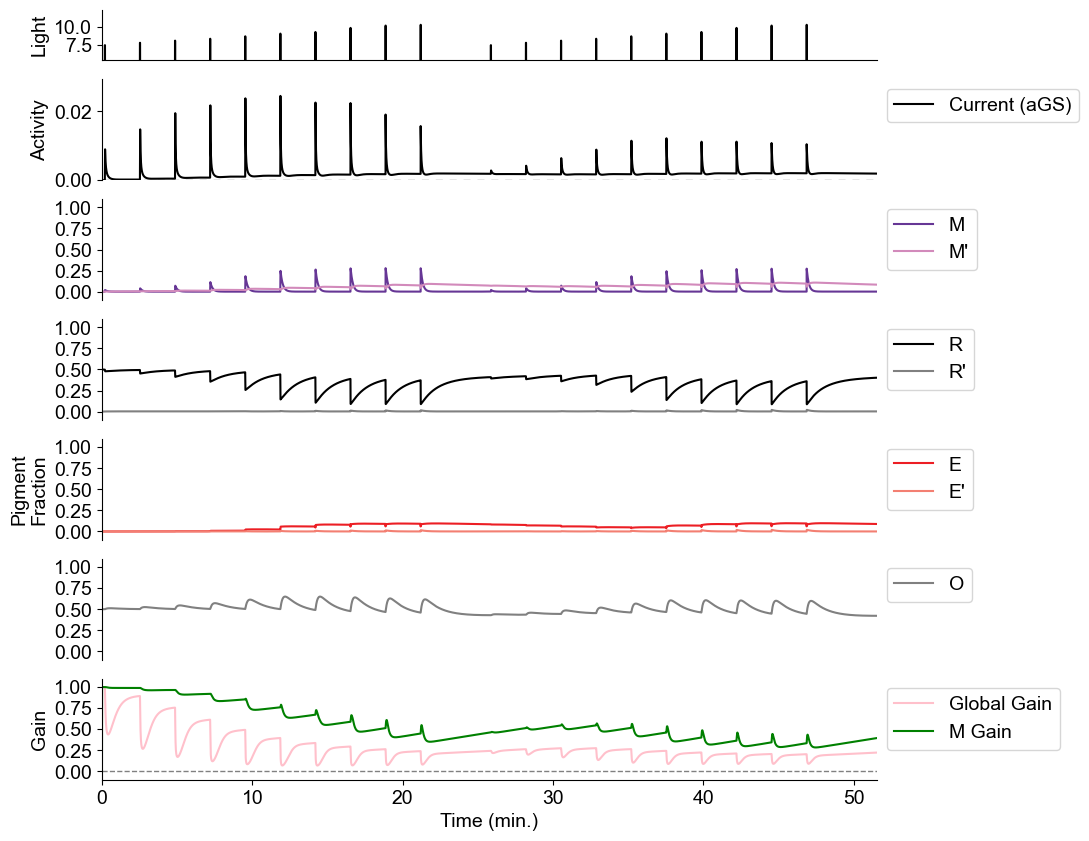

In [28]:
# Configuration dictionary in which the midpoint of the nonlinearity is left-shifted
Mprime_strong_feedback_config = {'x0_mg': 0.25} # Default is 0.381

# Run the model on the ocular-filtered xenon stimulus
Mprime_strong_feedback_result = predictMelanopsin(stimXenonEye, config=Mprime_strong_feedback_config)

# Plot the result
Mprime_strong_feedback_fig = plotModelRun(Mprime_strong_feedback_result)

Overlaying this model's prediction with the default indicates that stronger negative feedback reduces transient response amplitudes, especially  later on in the intensity-response relation. Note that persistent activity is relatively unaffected because it is driven by M'— whose signaling gain is untouched by M'-based negative feedback.

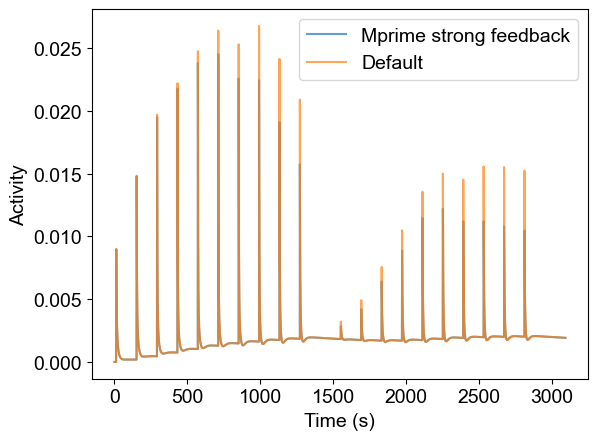

In [29]:
# Overlay model predictions
h_Mprime_strong_feedback = overlayModelActivity([Mprime_strong_feedback_result, xenon_eye_result], labels=['Mprime strong feedback', 'Default'])

## Simulations from our manuscript

Here we produce simulated responses to six stimulus protocols featured in our manuscript. Each is a pair of intensity-response relations of 1 sec steps of 440 nm, 560 nm, or Xenon light (with or without simulated ocular filtering).

440-440

Scale factor converting this spectrum to melanopsin (R state) equivalent 440 nm photons:  0.9684830699094698


The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

/content/melanopsin-model/myutils/model_functions.py:1268: RuntimeWarning: divide by zero encountered in log10
  logLightIntensity = np.log10(model['stimMonitor'])


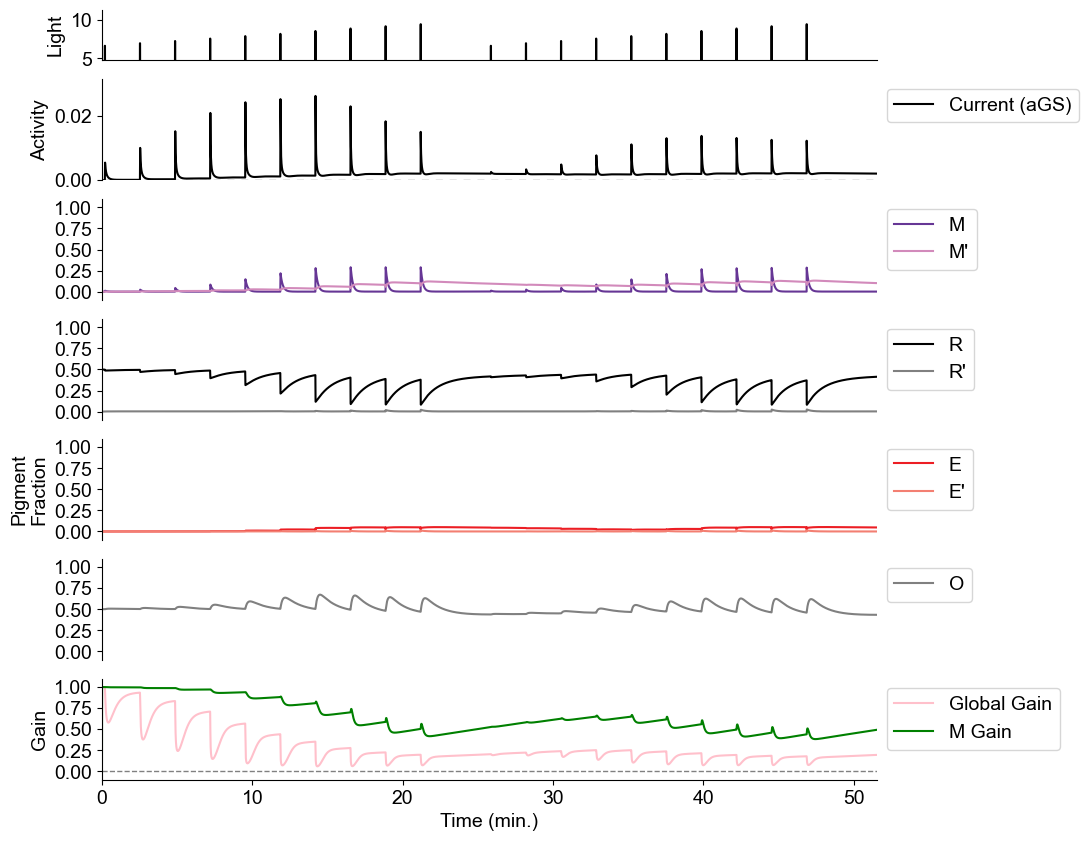

In [30]:
# Load a 440 nm - 440 nm stimulus (see our study for details)
stim440440 = setupModelRun("intensity response", "spectrum matched to 440", rate = 0.005, specwlen=wlenshared, specint=intensity440)

stim440440_result = predictMelanopsin(stim440440)

stim440440_fig = plotModelRun(stim440440_result)

560-560

Scale factor converting this spectrum to melanopsin (R state) equivalent 560 nm photons:  1.0170660797865752


The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

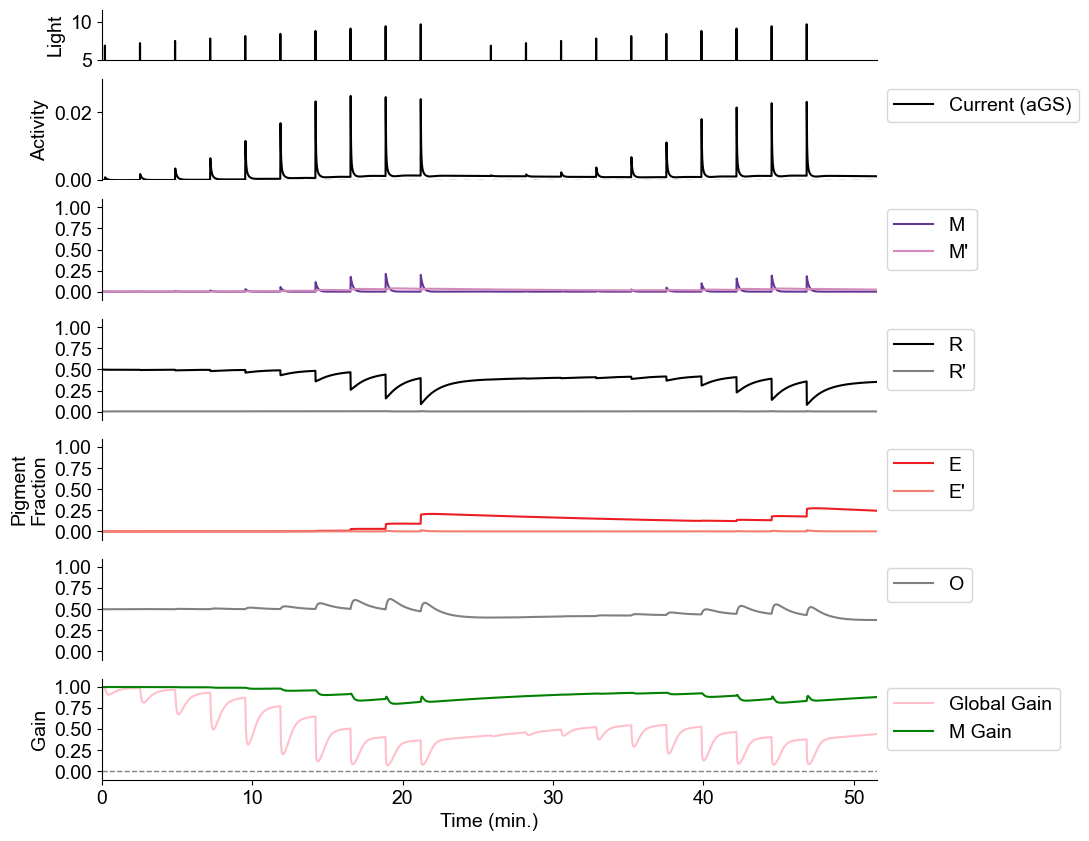

In [31]:
stim560560 = setupModelRun("intensity response", "spectrum matched to 560", rate = 0.005, specwlen=wlenshared, specint=intensity560)

stim560560_result = predictMelanopsin(stim560560)

stim560560_fig = plotModelRun(stim560560_result)

440-560

Scale factor converting this spectrum to melanopsin (R state) equivalent 440 nm photons:  0.9684830699094698
Scale factor converting this spectrum to melanopsin (R state) equivalent 560 nm photons:  1.0170660797865752


The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

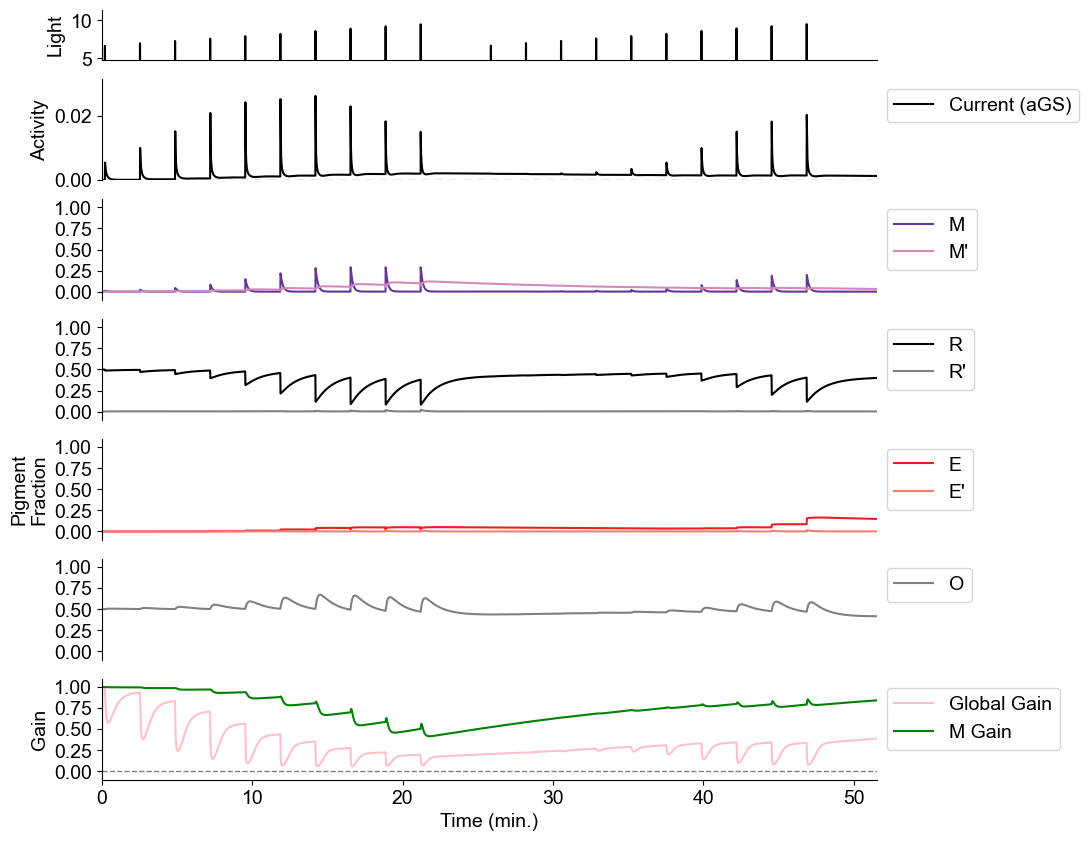

In [32]:
stim440560 = setupModelRun("intensity response", "spectrum matched to 440 560", rate = 0.005, specwlen = [wlenshared, wlenshared], specint = [intensity440, intensity560])

stim440560_result = predictMelanopsin(stim440560)

stim440560_fig = plotModelRun(stim440560_result)

560-440

Scale factor converting this spectrum to melanopsin (R state) equivalent 560 nm photons:  1.0170660797865752
Scale factor converting this spectrum to melanopsin (R state) equivalent 440 nm photons:  0.9684830699094698


The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

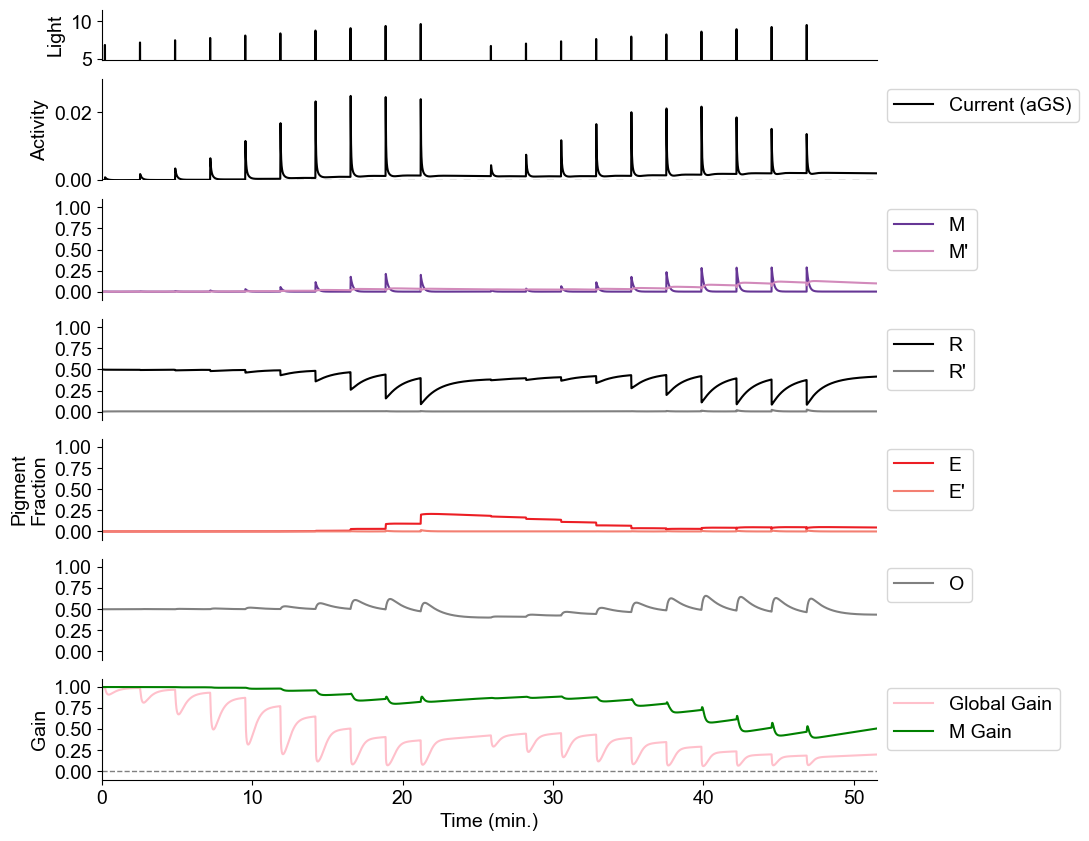

In [33]:
stim560440 = setupModelRun("intensity response", "spectrum matched to 560 440", rate = 0.005, specwlen = [wlenshared, wlenshared], specint = [intensity560, intensity440])

stim560440_result = predictMelanopsin(stim560440)

stim560440_fig = plotModelRun(stim560440_result)

Xenon

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

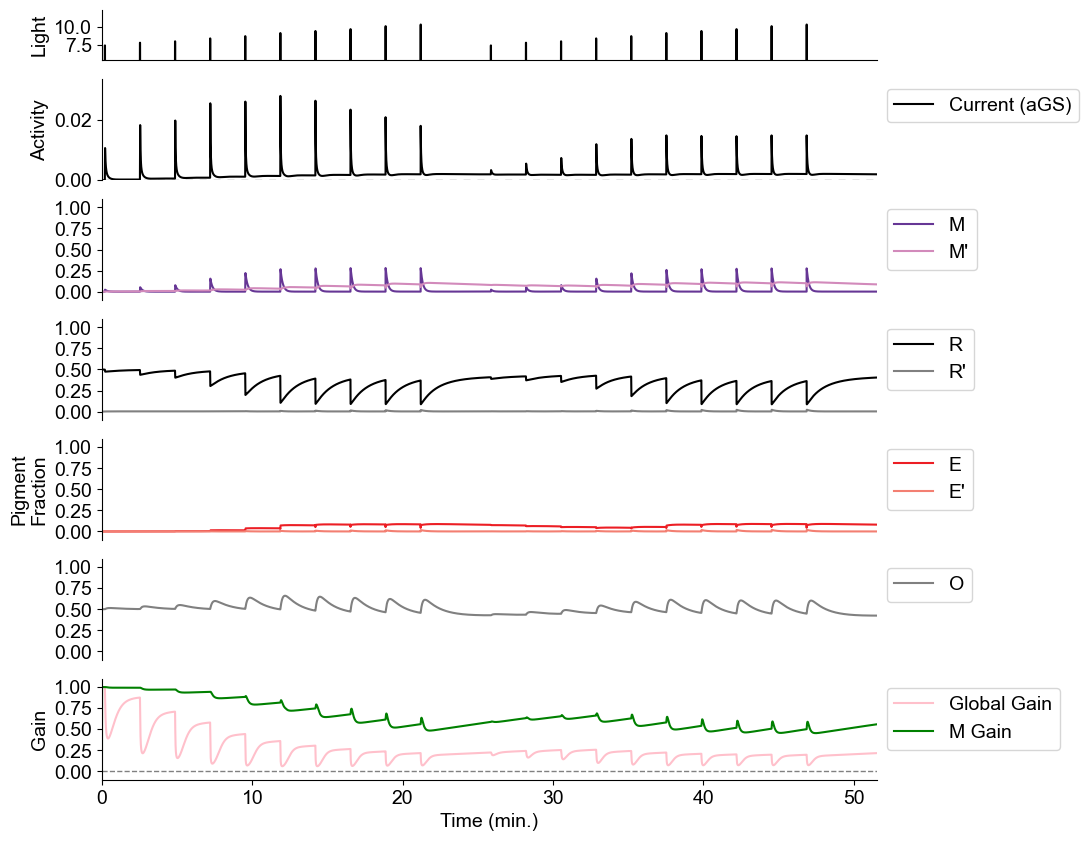

In [34]:
stimXenon = setupModelRun("intensity response", "xenon", rate = 0.005, specwlen=wlenshared, specint=xenon['photons'])

xenon_result = predictMelanopsin(stimXenon)

xenon_fig = plotModelRun(xenon_result)

Xenon with ocular filtering

The Main Loop:   0%|          | 0/309208 [00:00<?, ?it/s]

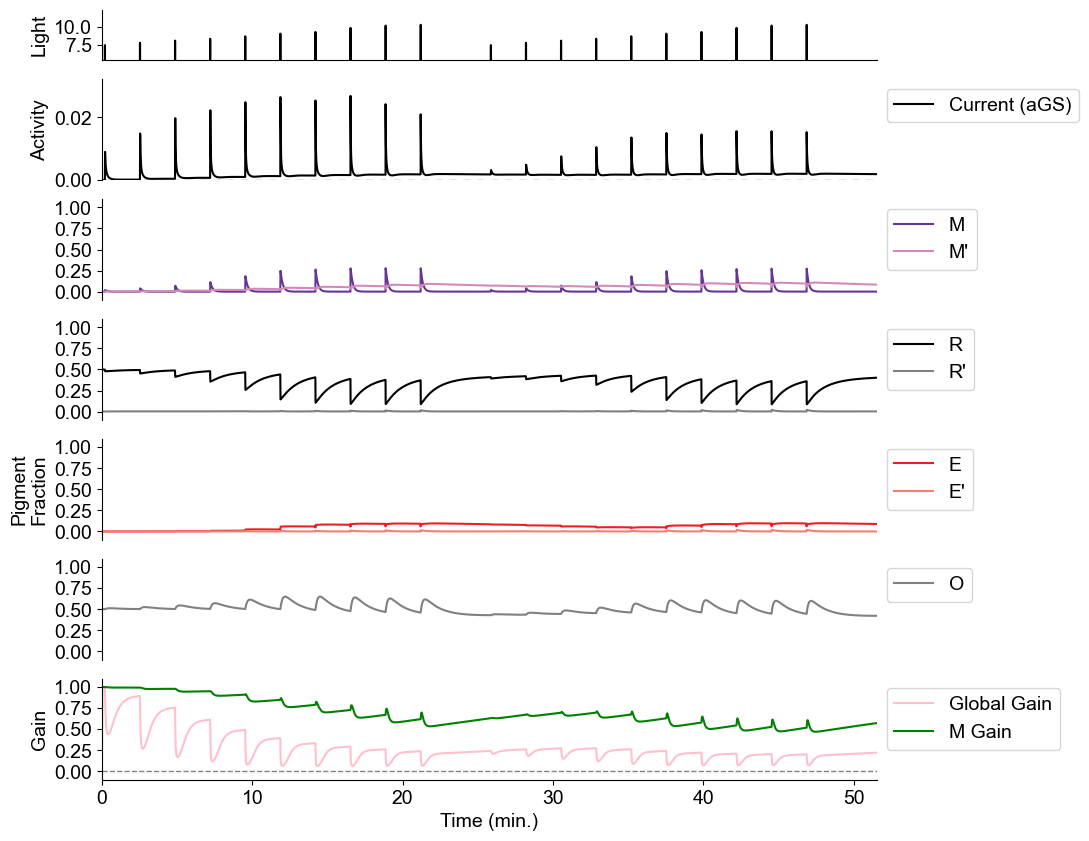

In [35]:
stimXenonEye = setupModelRun("intensity response", "xenon eye", rate = 0.005, specwlen=wlenshared, specint=xenon_eye['photons'])

xenon_eye_result = predictMelanopsin(stimXenonEye)

xenon_eye_fig = plotModelRun(xenon_eye_result)

# Closing remarks
We find this model useful for building intution for and generating hypotheses about melanopsin signaling. While its predictions closely fit electrical responses recorded from melanopsin neurons in our laboratory, imperfections remain. Some mechanisms in the model capture the data well but lack a definite biological analogy. We intend to update the model to incorporate future knowledge of melanopsin signaling.

**We welcome questions or comments. Please contact Michael Do (michael.do@childrens.harvard.edu) and Franklin Caval-Holme (franklin.caval-holme@childrens.harvard.edu)**